<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-9-Stochastically_Informed-NN/Untitled176.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Quantile Matching**

**Theoretical QQ Plot**

We generate $N$ data from a standard normal distribution. Then we plot the  quantiles of the empirical data distribution versus the quantiles of the theoretical N(0, 1) - distribution. We shall obtain the graph of the line $y=x$.   

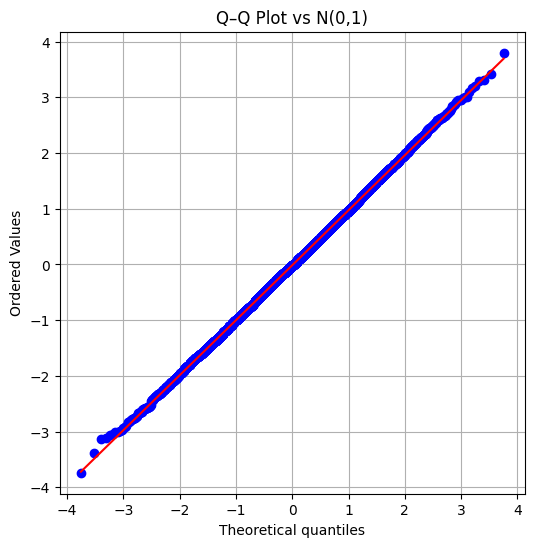

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step 1: generate data
N = 8000
np.random.seed(0)  # for reproducibility
data = np.random.normal(loc=0, scale=1, size=N)

# Step 2: Q-Q plot
plt.figure(figsize=(6,6))
stats.probplot(data, dist="norm", plot=plt)

plt.title("Q–Q Plot vs N(0,1)")
plt.grid(True)
plt.show()

If the data is not normalized, we use the transformation $Z = (X- m)/Var$, and then plot the QQ-plot against the N(0,1)-distribution.

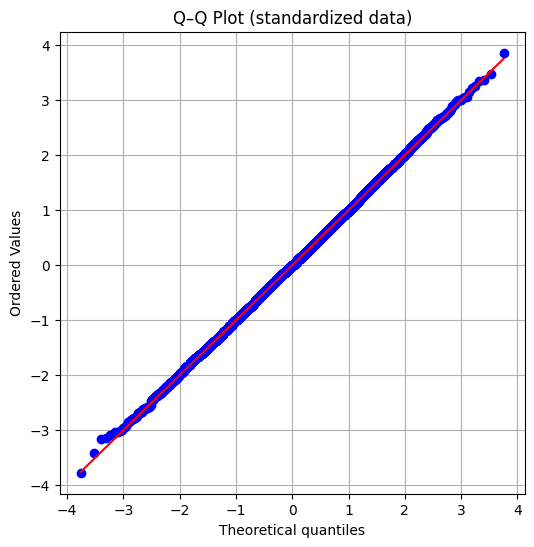

In [ ]:
# Standardize explicitly (not needed here, but good practice)
z = (data - np.mean(data)) / np.std(data)

plt.figure(figsize=(6,6))
stats.probplot(z, dist="norm", plot=plt)

plt.title("Q–Q Plot (standardized data)")
plt.grid(True)
plt.show()

**Manual QQ plot**

Here the quantiles are computed "manually". This procedure can be used in general for any distribution, not neccessarily normal.

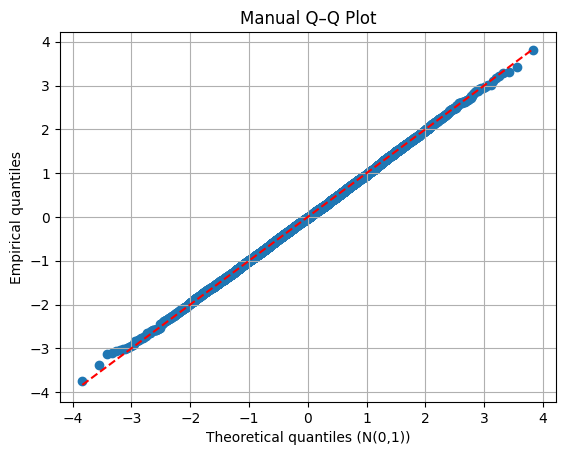

In [ ]:
# Sort data
x_sorted = np.sort(data)

# Theoretical quantiles
p = (np.arange(1, N+1) - 0.5) / N
z = stats.norm.ppf(p)

# Plot
plt.scatter(z, x_sorted)
plt.plot(z, z, 'r--')  # reference line y=x

plt.xlabel("Theoretical quantiles (N(0,1))")
plt.ylabel("Empirical quantiles")
plt.title("Manual Q–Q Plot")
plt.grid(True)
plt.show()

# **Learning a true distribution by a NN**

**Quantiles Matching Method**

We consider $N=100$ data points drawn from a known distribution, namely the standard normal distribution $\mathcal{N}(0,1)$. These samples define an empirical distribution $p^*$. Our goal is to reconstruct the true distribution $\mathcal{N}(0, 1)$  by learning a probability density $p_\theta$ using a neural network, as described above, by minimizing the quantile matching loss.

Epoch 0, Loss: 3.043825
Epoch 200, Loss: 1.173844
Epoch 400, Loss: 0.222650
Epoch 600, Loss: 0.045334
Epoch 800, Loss: 0.030880
Epoch 1000, Loss: 0.028540
Epoch 1200, Loss: 0.027233
Epoch 1400, Loss: 0.026098
Epoch 1600, Loss: 0.025110
Epoch 1800, Loss: 0.024239
Epoch 2000, Loss: 0.023491
Epoch 2200, Loss: 0.022825
Epoch 2400, Loss: 0.022224
Epoch 2600, Loss: 0.021679
Epoch 2800, Loss: 0.021183
Epoch 3000, Loss: 0.020727
Epoch 3200, Loss: 0.020308
Epoch 3400, Loss: 0.019913
Epoch 3600, Loss: 0.019536
Epoch 3800, Loss: 0.019179
Epoch 4000, Loss: 0.018854
Epoch 4200, Loss: 0.018519
Epoch 4400, Loss: 0.018196
Epoch 4600, Loss: 0.017894
Epoch 4800, Loss: 0.017579
Epoch 5000, Loss: 0.017238
Epoch 5200, Loss: 0.016890
Epoch 5400, Loss: 0.016448
Epoch 5600, Loss: 0.015950
Epoch 5800, Loss: 0.015363


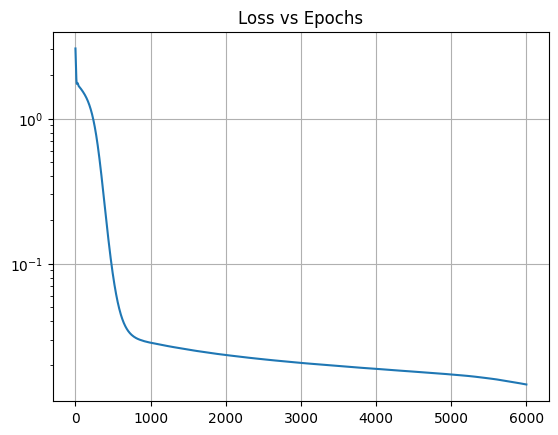

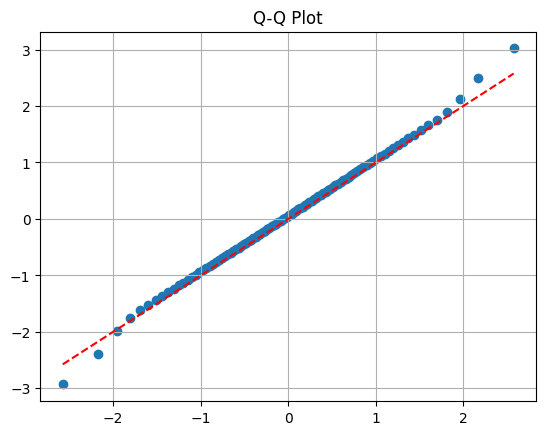

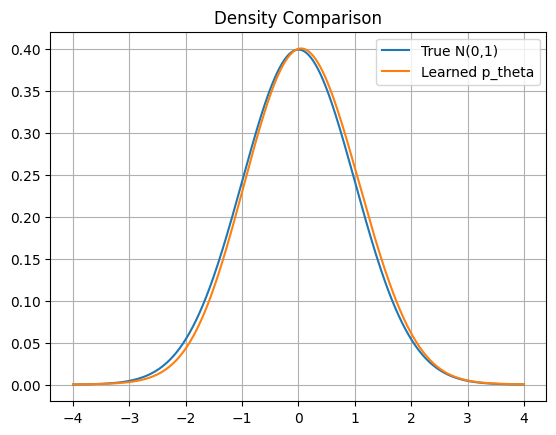

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import norm

# =========================
# Data
# =========================
np.random.seed(0)
N = 100
data = np.random.normal(0, 1, N)
data_sorted = np.sort(data)

u = (np.arange(1, N+1) - 0.5) / N

x_grid = np.linspace(-4, 4, 400).astype(np.float32)
dx = x_grid[1] - x_grid[0]

x_tf = tf.constant(x_grid.reshape(-1,1))
u_tf = tf.constant(u.reshape(-1,1), dtype=tf.float32)
data_tf = tf.constant(data_sorted.reshape(-1,1), dtype=tf.float32)

# =========================
# Model
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh'),
    #tf.keras.layers.Dense(64, activation='tanh'),

    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(1e-3)

alpha = 200.0  # sharpness of soft quantile

# =========================
# Training
# =========================
epochs =6000
loss_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        f_vals = model(x_tf)
        exp_f = tf.exp(f_vals)

        Z = tf.reduce_sum(exp_f) * dx
        p = exp_f / Z

        cdf = tf.cumsum(p) * dx  # shape (M,1)

        # Soft quantile (differentiable)
        cdf_expanded = tf.expand_dims(cdf, axis=1)  # (M,1,1)
        u_expanded = tf.expand_dims(u_tf, axis=0)   # (1,N,1)

        dist = tf.abs(cdf_expanded - u_expanded)    # (M,N,1)
        weights = tf.nn.softmax(-alpha * dist, axis=0)

        x_expanded = tf.expand_dims(x_tf, axis=1)   # (M,1,1)
        q_pred = tf.reduce_sum(weights * x_expanded, axis=0)  # (N,1)

        loss = tf.reduce_mean((q_pred - data_tf)**2)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(loss.numpy())

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.6f}")

# =========================
# Loss plot
# =========================
plt.plot(loss_history)
plt.yscale('log')
plt.title("Loss vs Epochs")
plt.grid()
plt.show()

# =========================
# Q-Q plot
# =========================
z_true = norm.ppf(u)

plt.scatter(z_true, q_pred.numpy().flatten())
plt.plot(z_true, z_true, 'r--')
plt.title("Q-Q Plot")
plt.grid()
plt.show()

# =========================
# Density plot
# =========================
p_theta = p.numpy().flatten()
p_true = norm.pdf(x_grid)

plt.plot(x_grid, p_true, label="True N(0,1)")
plt.plot(x_grid, p_theta, label="Learned p_theta")
plt.legend()
plt.title("Density Comparison")
plt.grid()
plt.show()

We redo the code using  a loss given by the Kullback--Leibler divergence
$$
L(\theta)
=
\mathrm{KL}(p^* \| p_\theta)
=
\int_{\mathbb{R}} p^*(x)\,\ln \frac{p^*(x)}{p_\theta(x)}\,dx
\;\geq\; 0.
$$

Epoch 0, Loss: 2.106285
Epoch 200, Loss: 1.559156
Epoch 400, Loss: 1.449479
Epoch 600, Loss: 1.443011
Epoch 800, Loss: 1.438593
Epoch 1000, Loss: 1.435522
Epoch 1200, Loss: 1.433160
Epoch 1400, Loss: 1.431103
Epoch 1600, Loss: 1.429117
Epoch 1800, Loss: 1.427177
Epoch 2000, Loss: 1.425505
Epoch 2200, Loss: 1.424280
Epoch 2400, Loss: 1.423409
Epoch 2600, Loss: 1.422725
Epoch 2800, Loss: 1.422112
Epoch 3000, Loss: 1.421526
Epoch 3200, Loss: 1.420948
Epoch 3400, Loss: 1.420372
Epoch 3600, Loss: 1.419792
Epoch 3800, Loss: 1.419204
Epoch 4000, Loss: 1.418553
Epoch 4200, Loss: 1.417618
Epoch 4400, Loss: 1.415920
Epoch 4600, Loss: 1.412118
Epoch 4800, Loss: 1.408109
Epoch 5000, Loss: 1.406972
Epoch 5200, Loss: 1.406273
Epoch 5400, Loss: 1.405585
Epoch 5600, Loss: 1.404797
Epoch 5800, Loss: 1.403855


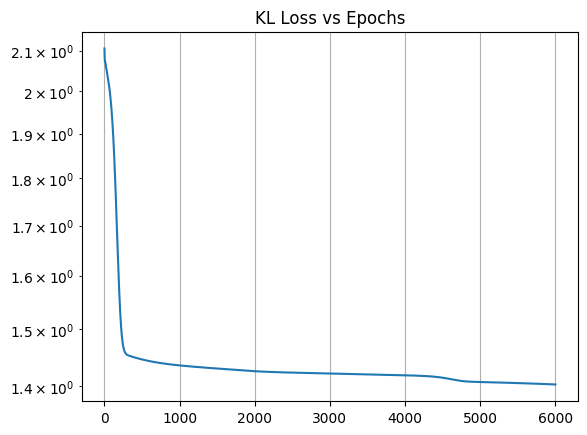

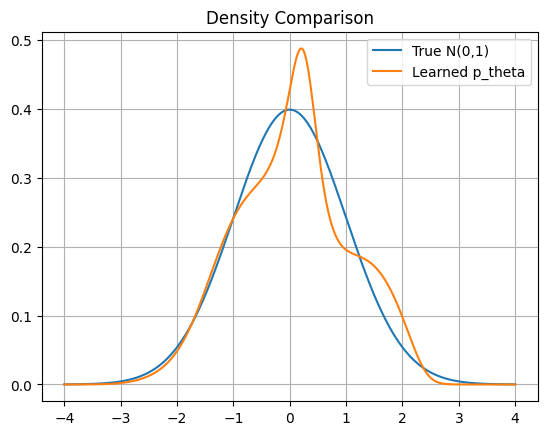

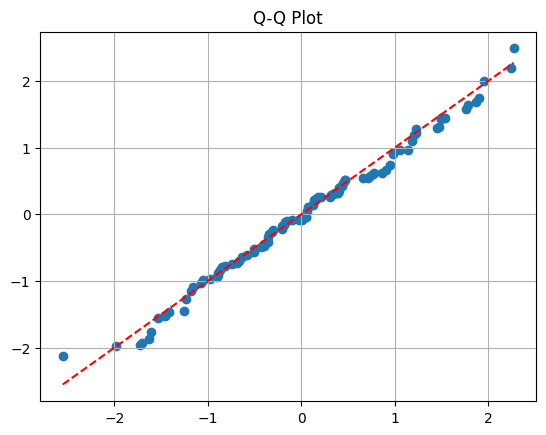

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import norm

# =========================
# 1. Data
# =========================
np.random.seed(0)
N = 100
data = np.random.normal(0, 1, N)

# =========================
# 2. Grid for normalization
# =========================
x_grid = np.linspace(-4, 4, 800).astype(np.float32)
dx = x_grid[1] - x_grid[0]

x_tf = tf.constant(x_grid.reshape(-1,1))
data_tf = tf.constant(data.reshape(-1,1), dtype=tf.float32)

# =========================
# 3. Neural density model
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh'),
    #tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(1e-3)

# =========================
# 4. Training (KL loss)
# =========================
epochs = 6000
loss_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        # Compute f(x) on grid
        f_grid = model(x_tf)
        exp_f = tf.exp(f_grid)

        # Partition function Z
        Z = tf.reduce_sum(exp_f) * dx

        # log p_theta on data
        f_data = model(data_tf)
        log_p = f_data - tf.math.log(Z)

        # KL(p* || p_theta) ~ -E_data[log p_theta]
        loss = -tf.reduce_mean(log_p)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history.append(loss.numpy())

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.6f}")

# =========================
# 5. Loss plot
# =========================
plt.figure()
plt.plot(loss_history)
plt.yscale('log')
plt.title("KL Loss vs Epochs")
plt.grid()
plt.show()

# =========================
# 6. Compute learned density
# =========================
f_grid = model(x_tf)
exp_f = tf.exp(f_grid)
Z = tf.reduce_sum(exp_f) * dx
p_theta = (exp_f / Z).numpy().flatten()

# True density
p_true = norm.pdf(x_grid)

# =========================
# 7. Density comparison
# =========================
plt.figure()
plt.plot(x_grid, p_true, label="True N(0,1)")
plt.plot(x_grid, p_theta, label="Learned p_theta")
plt.legend()
plt.title("Density Comparison")
plt.grid()
plt.show()

# =========================
# 8. Q-Q plot (sampling from model)
# =========================
cdf = np.cumsum(p_theta) * dx
cdf /= cdf[-1]

# sample from p_theta
u = np.random.rand(N)
samples_model = np.interp(u, cdf, x_grid)

# Q-Q
data_sorted = np.sort(data)
model_sorted = np.sort(samples_model)

plt.figure()
plt.scatter(data_sorted, model_sorted)
plt.plot(data_sorted, data_sorted, 'r--')
plt.title("Q-Q Plot")
plt.grid()
plt.show()